In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [3]:
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print(news_df.head())

   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00 

In [4]:
aapl_news = news_df[news_df['stock'] == 'AAPL'].copy()

print(aapl_news.head())

      Unnamed: 0                                           headline  \
6680        7120  Tech Stocks And FAANGS Strong Again To Start D...   
6681        7121      10 Biggest Price Target Changes For Wednesday   
6682        7122  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...   
6683        7123  Deutsche Bank Maintains Buy on Apple, Raises P...   
6684        7124  Apple To Let Users Trade In Their Mac Computer...   

                                                    url          publisher  \
6680  https://www.benzinga.com/government/20/06/1622...         JJ Kinahan   
6681  https://www.benzinga.com/analyst-ratings/price...         Lisa Levin   
6682  https://www.benzinga.com/short-sellers/20/06/1...  Benzinga Newsdesk   
6683  https://www.benzinga.com/news/20/06/16219873/d...  Benzinga Newsdesk   
6684  https://www.benzinga.com/news/20/06/16218697/a...      Neer Varshney   

                           date stock  
6680  2020-06-10 11:33:26-04:00  AAPL  
6681  2020-06-10 08:14:0

In [5]:
stock_df = pd.read_csv('../data/raw/AAPL.csv')

print(stock_df.head())

         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [6]:
aapl_news['date'] = pd.to_datetime(
    aapl_news['date'],
    format='mixed',
    utc=True,
    errors='coerce'
).dt.date

In [7]:
aapl_news['date'].isnull().sum()

np.int64(0)

In [8]:
print(aapl_news[['date']].head())

            date
6680  2020-06-10
6681  2020-06-10
6682  2020-06-10
6683  2020-06-10
6684  2020-06-10


In [9]:
stock_df['Date'] = pd.to_datetime(
    stock_df['Date'],
    errors='coerce'
).dt.date

In [10]:
stock_df['Date'].isnull().sum()

np.int64(0)

In [11]:
print("News Date Range:")
print(aapl_news['date'].min())
print(aapl_news['date'].max())

print("\nStock Date Range:")
print(stock_df['Date'].min())
print(stock_df['Date'].max())

News Date Range:
2020-03-09
2020-06-10

Stock Date Range:
2009-01-02
2023-12-29


In [12]:
len(aapl_news)

441

In [14]:
analyzer = SentimentIntensityAnalyzer()

In [15]:
sample_headline = aapl_news['headline'].iloc[0]

print(sample_headline)

print(analyzer.polarity_scores(sample_headline))

Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
{'neg': 0.0, 'neu': 0.705, 'pos': 0.295, 'compound': 0.5574}


In [17]:
aapl_news['sentiment_score'] = aapl_news['headline'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)

In [19]:
print(aapl_news[['headline', 'sentiment_score']].head())

                                               headline  sentiment_score
6680  Tech Stocks And FAANGS Strong Again To Start D...           0.5574
6681      10 Biggest Price Target Changes For Wednesday           0.0000
6682  Benzinga Pro's Top 5 Stocks To Watch For Wed.,...           0.2023
6683  Deutsche Bank Maintains Buy on Apple, Raises P...           0.0000
6684  Apple To Let Users Trade In Their Mac Computer...           0.3818


In [20]:
aapl_news['sentiment_score'].describe()

count    441.000000
mean       0.060997
std        0.332836
min       -0.906200
25%        0.000000
50%        0.000000
75%        0.296000
max        0.936000
Name: sentiment_score, dtype: float64

In [21]:
stock_df['daily_return'] = (
    stock_df['Close'].pct_change()
) * 100

In [22]:
stock_df[['Date', 'Close', 'daily_return']].head()

,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


In [23]:
stock_df['daily_return'].describe()

count    3773.000000
mean        0.128911
std         1.801011
min       -12.864700
25%        -0.754665
50%         0.106209
75%         1.077003
max        11.980808
Name: daily_return, dtype: float64

In [ ]:
# Daily stock returns were successfully calculated using percentage changes in Apple closing prices. The results showed both positive and negative daily movements, reflecting normal stock market volatility.
#
# The average daily return was slightly positive at approximately 0.13%, suggesting overall upward market performance during the observed period. However, the relatively large standard deviation indicates that substantial day-to-day price fluctuations occurred throughout the dataset.
#
# The maximum daily gain reached nearly 12%, while the largest daily loss exceeded -12%, highlighting periods of significant market volatility and strong investor reactions. These return patterns provide a useful basis for evaluating whether financial news sentiment is associated with stock market behavior.

In [24]:
daily_sentiment = aapl_news.groupby('date')['sentiment_score'].mean().reset_index()

daily_sentiment.head()

,date,sentiment_score
0,2020-03-09,-0.302067
1,2020-03-10,-0.090787
2,2020-03-11,-0.023850
3,2020-03-12,-0.207240
4,2020-03-13,-0.023191


In [25]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on='date',
    right_on='Date',
    how='inner'
)

merged_df.head()

,date,sentiment_score,Date,Close,High,Low,Open,Volume,daily_return
0,2020-03-09,-0.302067,2020-03-09,64.373756,67.256628,63.607082,63.788471,286744800,-7.909217
1,2020-03-10,-0.090787,2020-03-10,69.010056,69.276094,65.147678,67.026873,285290000,7.202157
2,2020-03-11,-0.023850,2020-03-11,66.613319,68.013645,65.749906,67.087355,255598800,-3.473025
3,2020-03-12,-0.207240,2020-03-12,60.034924,65.300043,59.979299,61.899604,418474000,-9.875496
4,2020-03-13,-0.023191,2020-03-13,67.227592,67.699207,61.176455,64.064172,370732000,11.980808


In [26]:
merged_df = merged_df[
    ['date', 'sentiment_score', 'daily_return']
]

merged_df.head()

,date,sentiment_score,daily_return
0,2020-03-09,-0.302067,-7.909217
1,2020-03-10,-0.090787,7.202157
2,2020-03-11,-0.023850,-3.473025
3,2020-03-12,-0.207240,-9.875496
4,2020-03-13,-0.023191,11.980808


In [27]:
merged_df.dropna(inplace=True)

In [28]:
correlation = merged_df['sentiment_score'].corr(
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.1239385418094221


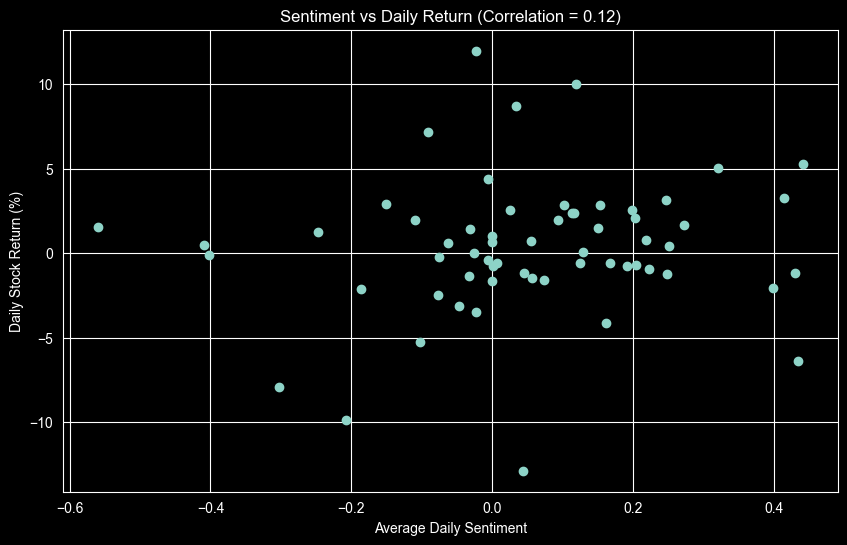

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged_df['sentiment_score'],
    merged_df['daily_return']
)

plt.title(
    f'Sentiment vs Daily Return (Correlation = {correlation:.2f})'
)

plt.xlabel('Average Daily Sentiment')

plt.ylabel('Daily Stock Return (%)')

plt.show()

In [30]:
def classify_sentiment(score):

    if score > 0.05:
        return 'Positive'

    elif score < -0.05:
        return 'Negative'

    else:
        return 'Neutral'


merged_df['sentiment_category'] = merged_df[
    'sentiment_score'
].apply(classify_sentiment)

In [31]:
category_returns = merged_df.groupby(
    'sentiment_category'
)['daily_return'].mean()

print(category_returns)

sentiment_category
Negative   -0.856267
Neutral     0.324812
Positive    0.920500
Name: daily_return, dtype: float64


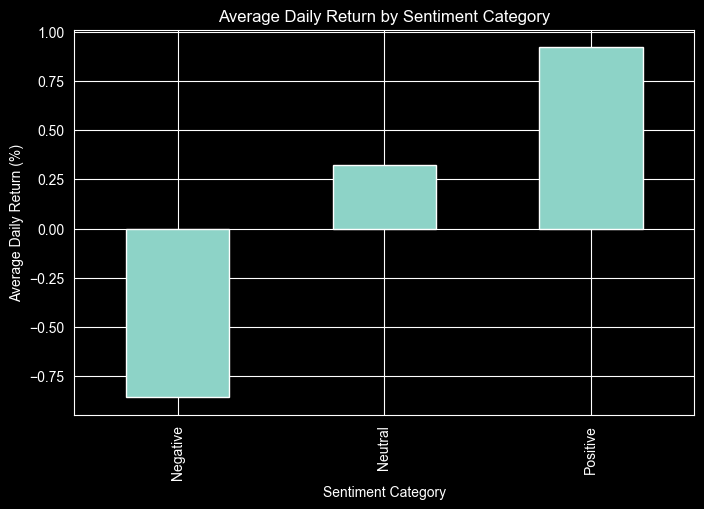

In [32]:
category_returns.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Daily Return by Sentiment Category')

plt.xlabel('Sentiment Category')

plt.ylabel('Average Daily Return (%)')

plt.show()

In [ ]:
# Daily average sentiment scores were successfully aggregated and aligned with Apple daily stock returns to evaluate the relationship between financial news sentiment and market performance.
#
# The Pearson correlation coefficient between sentiment scores and daily stock returns was approximately 0.12, indicating a weak positive relationship. This suggests that more positive financial news headlines were slightly associated with positive stock returns, although the relationship was not strong enough to serve as a highly reliable predictor on its own.
#
# The scatter plot visualization showed a broad dispersion of data points, indicating that many trading days experienced mismatches between sentiment direction and stock price movement. This highlights the complexity of financial markets, where stock prices are influenced by many additional factors beyond news sentiment alone.
#
# Further analysis using sentiment categories revealed a clearer directional pattern. Days classified as having positive sentiment produced the highest average daily return (approximately +0.92%), while negative sentiment days showed negative average returns (approximately -0.86%). Neutral sentiment days produced only modest positive returns.
#
# Overall, the results suggest that financial news sentiment may provide some useful market signal, particularly when aggregated by sentiment category, although its standalone predictive strength remains limited.